In [ ]:
!pip install optuna optuna-integration[tensorflow] tensorflow scikit-learn pandas numpy matplotlib seaborn plotly -q




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 10.5 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, SimpleRNN, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
from optuna.integration import TFKerasPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

Full dataset: 93,084 rows  |  2005-05-02 00:00:00  ->  2020-04-29 22:00:00
Using last 15,000 rows  |  2017-11-23 16:00:00  ->  2020-04-29 22:00:00
Target: BC  |  range: 1.0654 - 1.2548


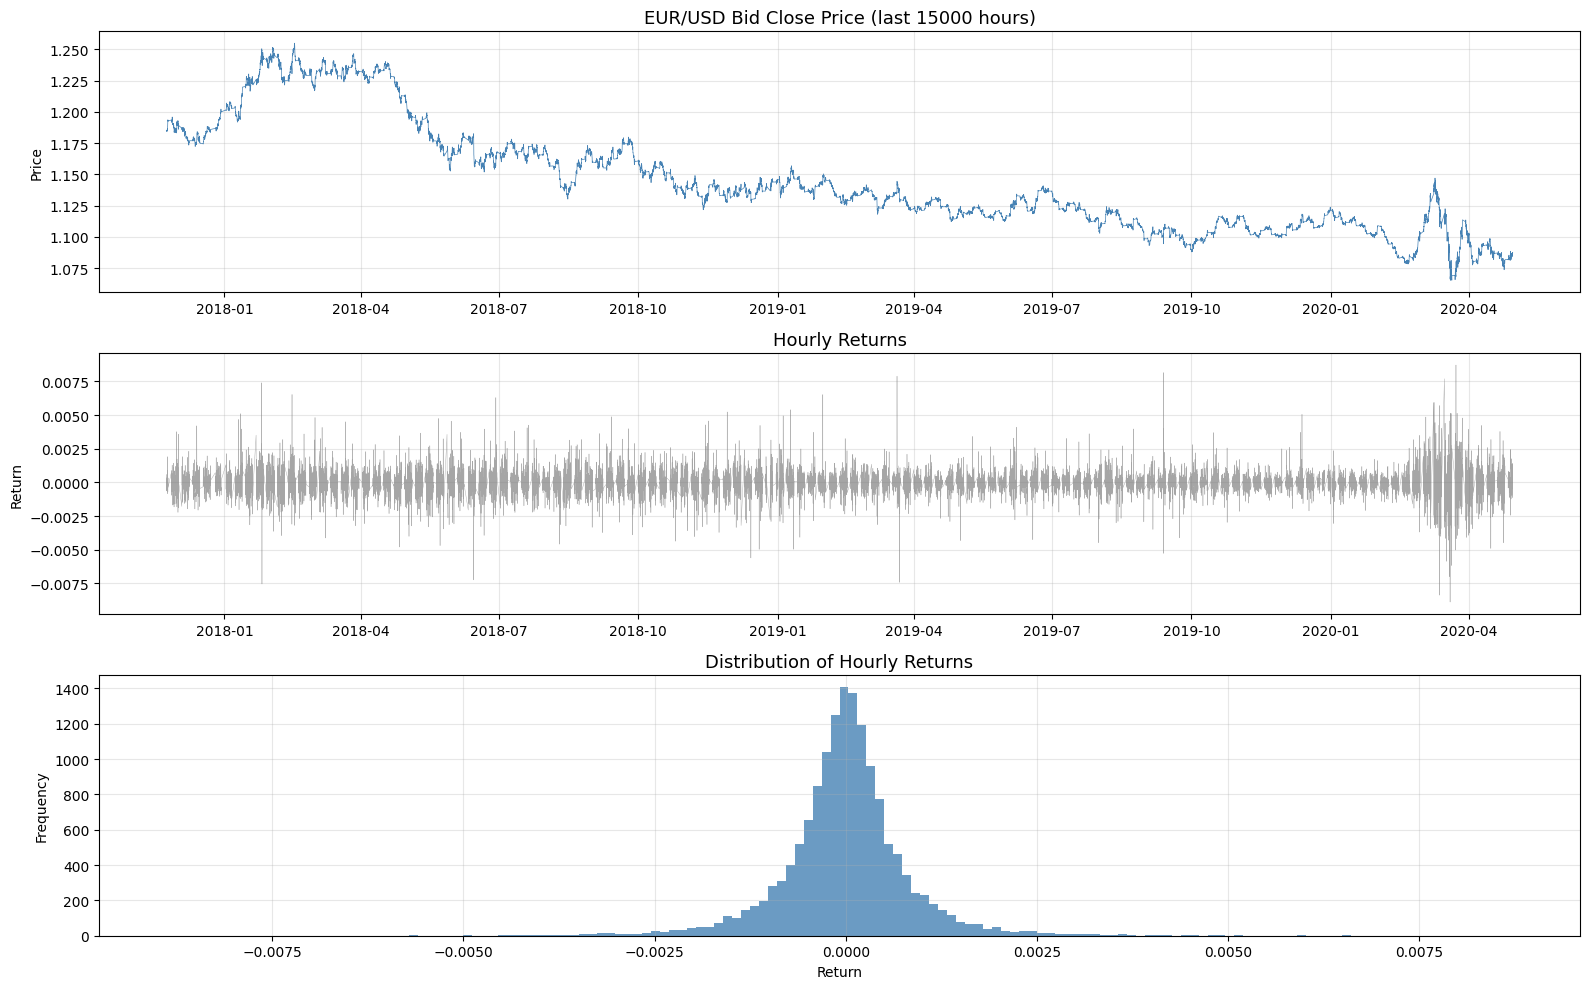

EDA saved.

Split — Train: 10500 | Val: 2250 | Test: 2250
Scaling done (fit on train only).

Sequence shapes:
  X_train: (10476, 24, 1)  X_val: (2226, 24, 1)  X_test: (2226, 24, 1)

  MODEL 1/3 — MLP
Training MLP baseline (30 epochs max)...
  Stopped at epoch 6

  MLP (Baseline) — TEST METRICS
  RMSE : 0.024107
  MAE  : 0.017595
  MAPE : 1.6185%
  R2   : -1.469034

Optuna MLP (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]

Best MLP val_loss: 0.00008840
Best MLP params:   {'n_layers': 1, 'lr': 0.0028579902593306246, 'dropout': 0.28513143089961207, 'units_0': 128}

Retraining tuned MLP (50 epochs max)...
  Stopped at epoch 25

  MLP (Tuned) — TEST METRICS
  RMSE : 0.008602
  MAE  : 0.006234
  MAPE : 0.5734%
  R2   : 0.685668

  MODEL 2/3 — RNN
Training RNN baseline (30 epochs max)...
  Stopped at epoch 18

  RNN (Baseline) — TEST METRICS
  RMSE : 0.002639
  MAE  : 0.001927
  MAPE : 0.1761%
  R2   : 0.970416

Optuna RNN (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]

Best RNN val_loss: 0.00004014
Best RNN params:   {'n_layers': 2, 'lr': 0.007612453094594895, 'dropout': 0.18246928496181658, 'units_0': 32, 'units_1': 64}

Retraining tuned RNN (50 epochs max)...
  Stopped at epoch 21

  RNN (Tuned) — TEST METRICS
  RMSE : 0.001785
  MAE  : 0.001169
  MAPE : 0.1064%
  R2   : 0.986458

  MODEL 3/3 — GRU
Training GRU baseline (30 epochs max)...
  Stopped at epoch 8

  GRU (Baseline) — TEST METRICS
  RMSE : 0.002291
  MAE  : 0.001572
  MAPE : 0.1432%
  R2   : 0.977701

Optuna GRU (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]

Best GRU val_loss: 0.00003175
Best GRU params:   {'n_layers': 2, 'lr': 0.0034530950905798338, 'dropout': 0.13984014717875573, 'units_0': 64, 'units_1': 32}

Retraining tuned GRU (50 epochs max)...
  Stopped at epoch 18

  GRU (Tuned) — TEST METRICS
  RMSE : 0.001587
  MAE  : 0.001071
  MAPE : 0.0975%
  R2   : 0.989296

FINAL MODEL COMPARISON — RANKED BY RMSE
            Model      RMSE       MAE      MAPE        R2
1     GRU (Tuned)  0.001587  0.001071  0.097518  0.989296
2     RNN (Tuned)  0.001785  0.001169  0.106405  0.986458
3  GRU (Baseline)  0.002291  0.001572  0.143195  0.977701
4  RNN (Baseline)  0.002639  0.001927  0.176144  0.970416
5     MLP (Tuned)  0.008602  0.006234  0.573353  0.685668
6  MLP (Baseline)  0.024107  0.017595  1.618535 -1.469034


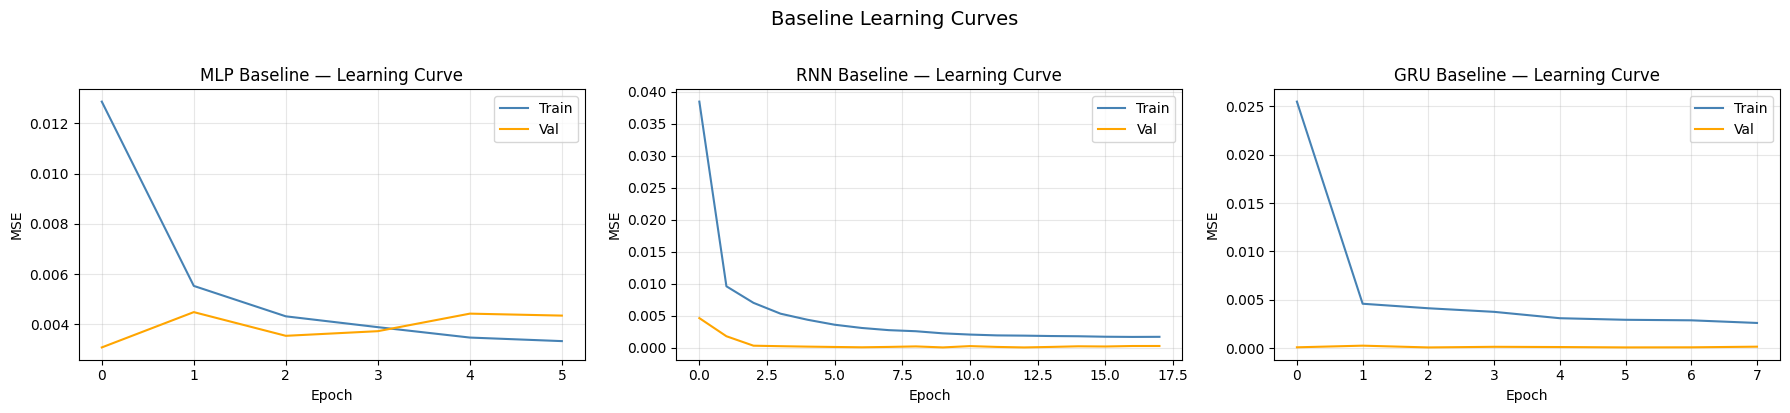

TypeError: 'History' object is not subscriptable

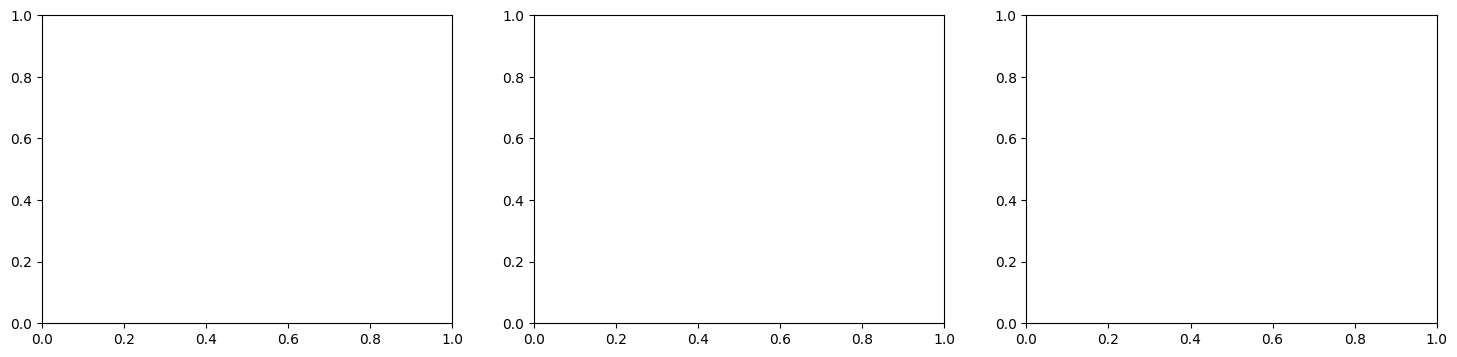

In [ ]:
PATH = "eurusd_hour.csv"

df = pd.read_csv(PATH)
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.set_index('Datetime').sort_index()
df = df.drop(columns=['Date', 'Time'])

print(f"Full dataset: {df.shape[0]:,} rows  |  {df.index.min()}  ->  {df.index.max()}")

# ============================================================
#  SPEED FIX 1 — USE RECENT SUBSET ONLY
#  Full 93k rows means 65k training sequences.
#  15k rows = ~10k training sequences — trains 6x faster
#  while still covering ~2 years of hourly data.
# ============================================================
N_ROWS = 15_000
df = df.iloc[-N_ROWS:].copy()
print(f"Using last {N_ROWS:,} rows  |  {df.index.min()}  ->  {df.index.max()}")

target_col = 'BC'
print(f"Target: {target_col}  |  range: {df[target_col].min():.4f} - {df[target_col].max():.4f}")

# ============================================================
#  EDA  (lightweight — 3 subplots)
# ============================================================
returns = df[target_col].pct_change().dropna()

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
axes[0].plot(df.index, df[target_col], linewidth=0.5, color='steelblue')
axes[0].set_title(f'EUR/USD Bid Close Price (last {N_ROWS} hours)', fontsize=13)
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

axes[1].plot(returns.index, returns, linewidth=0.3, color='gray', alpha=0.7)
axes[1].set_title('Hourly Returns', fontsize=13)
axes[1].set_ylabel('Return')
axes[1].grid(True, alpha=0.3)

axes[2].hist(returns, bins=150, color='steelblue', edgecolor='none', alpha=0.8)
axes[2].set_title('Distribution of Hourly Returns', fontsize=13)
axes[2].set_xlabel('Return')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA saved.")

# ============================================================
#  TRAIN / VAL / TEST SPLIT  (70 / 15 / 15)
# ============================================================
series = df[[target_col]].values
n = len(series)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_raw = series[:train_end]
val_raw   = series[train_end:val_end]
test_raw  = series[val_end:]

print(f"\nSplit — Train: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}")

scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)
print("Scaling done (fit on train only).")

# ============================================================
#  SPEED FIX 2 — FIXED LOOKBACK = 24
#  Searching lookback (12-72) rebuilds sequences each trial.
#  Fixing at 24 (1 trading day) pre-builds sequences once
#  and reuses them across all trials — saves significant time.
# ============================================================
LOOKBACK = 24

def create_sequences(data, lookback=LOOKBACK):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_val,   y_val   = create_sequences(val_scaled)
X_test,  y_test  = create_sequences(test_scaled)

# Pre-flatten for MLP (done once, not per trial)
X_train_mlp = X_train.reshape(X_train.shape[0], -1)
X_val_mlp   = X_val.reshape(X_val.shape[0], -1)
X_test_mlp  = X_test.reshape(X_test.shape[0], -1)

print(f"\nSequence shapes:")
print(f"  X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

# ============================================================
#  SHARED HELPERS
# ============================================================
def evaluate_model(model_name, y_true_scaled, y_pred_scaled):
    y_true = scaler.inverse_transform(y_true_scaled)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f"  {model_name} — TEST METRICS")
    print(f"{'='*45}")
    print(f"  RMSE : {rmse:.6f}")
    print(f"  MAE  : {mae:.6f}")
    print(f"  MAPE : {mape:.4f}%")
    print(f"  R2   : {r2:.6f}")
    print(f"{'='*45}")
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2,
            'y_true': y_true, 'y_pred': y_pred}

def get_callbacks(patience_es=5, patience_lr=3):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_es,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=patience_lr, min_lr=1e-6, verbose=0)
    ]

def clear_memory():
    gc.collect()
    tf.keras.backend.clear_session()

# ============================================================
#  OPTUNA SETTINGS
# ============================================================
N_TRIALS    = 15    # per model — was 30
EPOCHS_TUNE = 15    # per trial — was 30
EPOCHS_BASE = 30    # baseline  — was 100
EPOCHS_FULL = 50    # final retrain — was 150
BATCH_SIZE  = 64    # fixed — was searched

pruner = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=3)

# ============================================================
#  ── MODEL 1: MLP ────────────────────────────────────────────
# ============================================================
print("\n" + "="*55)
print("  MODEL 1/3 — MLP")
print("="*55)

# Baseline
mlp_base = Sequential([
    Input(shape=(X_train_mlp.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
], name='MLP_Baseline')
mlp_base.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])

print(f"Training MLP baseline ({EPOCHS_BASE} epochs max)...")
hist_mlp_base = mlp_base.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=EPOCHS_BASE, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(patience_es=5), verbose=0
)
print(f"  Stopped at epoch {len(hist_mlp_base.history['loss'])}")
res_mlp_base = evaluate_model('MLP (Baseline)', y_test, mlp_base.predict(X_test_mlp, verbose=0))

# Optuna
def objective_mlp(trial):
    clear_memory()
    n_layers = trial.suggest_int('n_layers', 1, 3)
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout  = trial.suggest_float('dropout', 0.0, 0.4)

    model = Sequential(name='MLP_Trial')
    model.add(Input(shape=(X_train_mlp.shape[1],)))
    for i in range(n_layers):
        units = trial.suggest_int(f'units_{i}', 32, 128, step=32)
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mse')

    model.fit(
        X_train_mlp, y_train,
        validation_data=(X_val_mlp, y_val),
        epochs=EPOCHS_TUNE, batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                 restore_best_weights=True),
                   TFKerasPruningCallback(trial, 'val_loss')],
        verbose=0
    )
    val_loss = model.evaluate(X_val_mlp, y_val, verbose=0)
    del model
    return val_loss

print(f"\nOptuna MLP ({N_TRIALS} trials)...")
study_mlp = optuna.create_study(direction='minimize', pruner=pruner, study_name='MLP')
study_mlp.optimize(objective_mlp, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best MLP val_loss: {study_mlp.best_value:.8f}")
print(f"Best MLP params:   {study_mlp.best_params}")

# Retrain best MLP
clear_memory()
p = study_mlp.best_params
mlp_tuned = Sequential(name='MLP_Tuned')
mlp_tuned.add(Input(shape=(X_train_mlp.shape[1],)))
for i in range(p['n_layers']):
    mlp_tuned.add(Dense(p[f'units_{i}'], activation='relu'))
    mlp_tuned.add(Dropout(p['dropout']))
mlp_tuned.add(Dense(1))
mlp_tuned.compile(optimizer=Adam(p['lr']), loss='mse', metrics=['mae'])

print(f"\nRetraining tuned MLP ({EPOCHS_FULL} epochs max)...")
hist_mlp_tuned = mlp_tuned.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=EPOCHS_FULL, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(patience_es=8), verbose=0
)
print(f"  Stopped at epoch {len(hist_mlp_tuned.history['loss'])}")
res_mlp_tuned = evaluate_model('MLP (Tuned)', y_test, mlp_tuned.predict(X_test_mlp, verbose=0))
res_mlp_tuned['history'] = hist_mlp_tuned

# ============================================================
#  ── MODEL 2: RNN ────────────────────────────────────────────
# ============================================================
print("\n" + "="*55)
print("  MODEL 2/3 — RNN")
print("="*55)

# Baseline
clear_memory()
rnn_base = Sequential([
    Input(shape=(LOOKBACK, 1)),
    SimpleRNN(32, activation='tanh', return_sequences=True),
    Dropout(0.2),
    SimpleRNN(16, activation='tanh'),
    Dropout(0.2),
    Dense(1)
], name='RNN_Baseline')
rnn_base.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])

print(f"Training RNN baseline ({EPOCHS_BASE} epochs max)...")
hist_rnn_base = rnn_base.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_BASE, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(patience_es=5), verbose=0
)
print(f"  Stopped at epoch {len(hist_rnn_base.history['loss'])}")
res_rnn_base = evaluate_model('RNN (Baseline)', y_test, rnn_base.predict(X_test, verbose=0))

# Optuna
def objective_rnn(trial):
    clear_memory()
    n_layers = trial.suggest_int('n_layers', 1, 2)
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout  = trial.suggest_float('dropout', 0.0, 0.4)

    model = Sequential(name='RNN_Trial')
    model.add(Input(shape=(LOOKBACK, 1)))
    for i in range(n_layers):
        units = trial.suggest_int(f'units_{i}', 16, 64, step=16)
        model.add(SimpleRNN(units, activation='tanh',
                            return_sequences=(i < n_layers - 1)))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mse')

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS_TUNE, batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                 restore_best_weights=True),
                   TFKerasPruningCallback(trial, 'val_loss')],
        verbose=0
    )
    val_loss = model.evaluate(X_val, y_val, verbose=0)
    del model
    return val_loss

print(f"\nOptuna RNN ({N_TRIALS} trials)...")
study_rnn = optuna.create_study(direction='minimize', pruner=pruner, study_name='RNN')
study_rnn.optimize(objective_rnn, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best RNN val_loss: {study_rnn.best_value:.8f}")
print(f"Best RNN params:   {study_rnn.best_params}")

# Retrain best RNN
clear_memory()
p = study_rnn.best_params
rnn_tuned = Sequential(name='RNN_Tuned')
rnn_tuned.add(Input(shape=(LOOKBACK, 1)))
for i in range(p['n_layers']):
    rnn_tuned.add(SimpleRNN(p[f'units_{i}'], activation='tanh',
                            return_sequences=(i < p['n_layers'] - 1)))
    rnn_tuned.add(Dropout(p['dropout']))
rnn_tuned.add(Dense(1))
rnn_tuned.compile(optimizer=Adam(p['lr']), loss='mse', metrics=['mae'])

print(f"\nRetraining tuned RNN ({EPOCHS_FULL} epochs max)...")
hist_rnn_tuned = rnn_tuned.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FULL, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(patience_es=8), verbose=0
)
print(f"  Stopped at epoch {len(hist_rnn_tuned.history['loss'])}")
res_rnn_tuned = evaluate_model('RNN (Tuned)', y_test, rnn_tuned.predict(X_test, verbose=0))
res_rnn_tuned['history'] = hist_rnn_tuned

# ============================================================
#  ── MODEL 3: GRU ────────────────────────────────────────────
# ============================================================
print("\n" + "="*55)
print("  MODEL 3/3 — GRU")
print("="*55)

# Baseline
clear_memory()
gru_base = Sequential([
    Input(shape=(LOOKBACK, 1)),
    GRU(32, return_sequences=True),
    Dropout(0.2),
    GRU(16),
    Dropout(0.2),
    Dense(1)
], name='GRU_Baseline')
gru_base.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])

print(f"Training GRU baseline ({EPOCHS_BASE} epochs max)...")
hist_gru_base = gru_base.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_BASE, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(patience_es=5), verbose=0
)
print(f"  Stopped at epoch {len(hist_gru_base.history['loss'])}")
res_gru_base = evaluate_model('GRU (Baseline)', y_test, gru_base.predict(X_test, verbose=0))

# Optuna
def objective_gru(trial):
    clear_memory()
    n_layers = trial.suggest_int('n_layers', 1, 2)
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout  = trial.suggest_float('dropout', 0.0, 0.4)

    model = Sequential(name='GRU_Trial')
    model.add(Input(shape=(LOOKBACK, 1)))
    for i in range(n_layers):
        units = trial.suggest_int(f'units_{i}', 16, 64, step=16)
        model.add(GRU(units, return_sequences=(i < n_layers - 1)))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mse')

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS_TUNE, batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                 restore_best_weights=True),
                   TFKerasPruningCallback(trial, 'val_loss')],
        verbose=0
    )
    val_loss = model.evaluate(X_val, y_val, verbose=0)
    del model
    return val_loss

print(f"\nOptuna GRU ({N_TRIALS} trials)...")
study_gru = optuna.create_study(direction='minimize', pruner=pruner, study_name='GRU')
study_gru.optimize(objective_gru, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best GRU val_loss: {study_gru.best_value:.8f}")
print(f"Best GRU params:   {study_gru.best_params}")

# Retrain best GRU
clear_memory()
p = study_gru.best_params
gru_tuned = Sequential(name='GRU_Tuned')
gru_tuned.add(Input(shape=(LOOKBACK, 1)))
for i in range(p['n_layers']):
    gru_tuned.add(GRU(p[f'units_{i}'], return_sequences=(i < p['n_layers'] - 1)))
    gru_tuned.add(Dropout(p['dropout']))
gru_tuned.add(Dense(1))
gru_tuned.compile(optimizer=Adam(p['lr']), loss='mse', metrics=['mae'])

print(f"\nRetraining tuned GRU ({EPOCHS_FULL} epochs max)...")
hist_gru_tuned = gru_tuned.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FULL, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(patience_es=8), verbose=0
)
print(f"  Stopped at epoch {len(hist_gru_tuned.history['loss'])}")
res_gru_tuned = evaluate_model('GRU (Tuned)', y_test, gru_tuned.predict(X_test, verbose=0))
res_gru_tuned['history'] = hist_gru_tuned

# ============================================================
#  FINAL RESULTS TABLE
# ============================================================
all_results = [
    res_mlp_base, res_rnn_base, res_gru_base,
    res_mlp_tuned, res_rnn_tuned, res_gru_tuned
]

all_results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_true', 'y_pred', 'history']}
    for r in all_results
]).sort_values('RMSE').reset_index(drop=True)
all_results_df.index += 1

print("\n" + "="*70)
print("FINAL MODEL COMPARISON — RANKED BY RMSE")
print("="*70)
print(all_results_df.to_string())
print("="*70)

# ============================================================
#  PLOTS
# ============================================================

# 1. Learning curves — baselines
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, hist, name in zip(axes,
                           [hist_mlp_base, hist_rnn_base, hist_gru_base],
                           ['MLP', 'RNN', 'GRU']):
    ax.plot(hist.history['loss'],     label='Train', color='steelblue')
    ax.plot(hist.history['val_loss'], label='Val',   color='orange')
    ax.set_title(f'{name} Baseline — Learning Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Baseline Learning Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('baseline_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# 2. Learning curves — tuned
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, hist, name in zip(axes,
                           [hist_mlp_tuned['history'], hist_rnn_tuned['history'], hist_gru_tuned['history']],
                           ['MLP (Tuned)', 'RNN (Tuned)', 'GRU (Tuned)']):
    ax.plot(hist.history['loss'],     label='Train', color='steelblue')
    ax.plot(hist.history['val_loss'], label='Val',   color='orange')
    ax.set_title(f'{name} — Learning Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Tuned Learning Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('tuned_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# 3. Optuna history
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, study, name in zip(axes, [study_mlp, study_rnn, study_gru], ['MLP', 'RNN', 'GRU']):
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = [min(vals[:i+1]) for i in range(len(vals))]
    ax.plot(vals, color='gray', alpha=0.5, marker='o', markersize=3, label='Trial loss')
    ax.plot(best_so_far, color='red', linewidth=2, label='Best so far')
    ax.set_title(f'{name} — Optuna History')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Val Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=120, bbox_inches='tight')
plt.show()

# 4. Actual vs Predicted — tuned models
PLOT_N = 300
fig, axes = plt.subplots(3, 1, figsize=(16, 11))
for ax, res, color in zip(axes,
                           [res_mlp_tuned, res_rnn_tuned, res_gru_tuned],
                           ['steelblue', 'darkorange', 'green']):
    ax.plot(res['y_true'][-PLOT_N:], label='Actual',    color='black', linewidth=1.2)
    ax.plot(res['y_pred'][-PLOT_N:], label=res['Model'],color=color,   linewidth=1.0, alpha=0.85)
    ax.set_title(f"{res['Model']} — Actual vs Predicted (last {PLOT_N} hours)")
    ax.set_ylabel('EUR/USD')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tuned_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

# 5. Metric bar chart
metrics  = ['RMSE', 'MAE', 'MAPE']
model_order = ['MLP (Baseline)', 'MLP (Tuned)',
               'RNN (Baseline)', 'RNN (Tuned)',
               'GRU (Baseline)', 'GRU (Tuned)']
colors = ['#a8c8e8','#2176ae', '#f5c07a','#f4a261', '#a8d5a2','#2a9d4a']
plot_df = all_results_df.set_index('Model').reindex(model_order)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, metrics):
    vals = plot_df[metric].values
    bars = ax.bar(model_order, vals, color=colors, edgecolor='white')
    ax.set_title(f'{metric} Comparison')
    ax.set_xticklabels(model_order, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.5f}', ha='center', va='bottom', fontsize=7)
plt.suptitle('Baseline vs Tuned — Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=120, bbox_inches='tight')
plt.show()

# 6. Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_res = [res_mlp_base, res_rnn_base, res_gru_base,
            res_mlp_tuned, res_rnn_tuned, res_gru_tuned]
for ax, res in zip(axes.flat, plot_res):
    ax.scatter(res['y_true'], res['y_pred'], alpha=0.05, s=1, color='steelblue')
    lims = [min(res['y_true'].min(), res['y_pred'].min()),
            max(res['y_true'].max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f"{res['Model']}  (R²={res['R2']:.4f})", fontsize=11)
    ax.grid(True, alpha=0.2)
plt.suptitle('Actual vs Predicted Scatter — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('scatter_actual_vs_pred.png', dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
#  SAVE RESULTS
# ============================================================
all_results_df.to_csv('model_results.csv', index=False)

print("\n" + "="*70)
print("BEST HYPERPARAMETERS FOUND BY OPTUNA")
print("="*70)
for study, name in [(study_mlp, 'MLP'), (study_rnn, 'RNN'), (study_gru, 'GRU')]:
    print(f"\n  {name}:")
    for k, v in study.best_params.items():
        print(f"    {k:20s}: {v}")

print("\n" + "="*70)
print("ALL DONE — Output files:")
print("  eda_plots.png               baseline_learning_curves.png")
print("  tuned_learning_curves.png   optuna_history.png")
print("  tuned_predictions.png       model_comparison_bar.png")
print("  scatter_actual_vs_pred.png  model_results.csv")
print("="*70)
